# 00. field3 데이터 감사

3차 현장실험에서 수집한 lane autolabel 데이터를 학습에 바로 써도 되는지 확인하는 노트북임.

이번 노트북에서 보는 것:

```text
raw / labels / masks / overlays 개수
manifest와 실제 파일의 불일치
.lines.txt 라벨 통계
usable / reject 분포
overlay 샘플 확인
```

중요한 점:

```text
scene 태그는 학습 클래스가 아님.
수집 중 scene 키가 섞였으므로 전체를 field_drive라는 하나의 실제 주행 도메인으로 취급함.
```


In [1]:
from pathlib import Path
import csv
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
SESSION_ROOT = PROJECT_ROOT / "10_experiments" / "10_lane_autolabel_collection" / "outputs" / "20260501_191218_lane_autolabel_drive"
EXPERIMENT_ROOT = PROJECT_ROOT / "10_experiments" / "11_clrkdnet_precision_tuning"
OUT_DIR = EXPERIMENT_ROOT / "review_outputs" / "00_field3_data_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR = SESSION_ROOT / "raw" / "field_drive"
LABEL_DIR = SESSION_ROOT / "labels" / "field_drive"
MASK_DIR = SESSION_ROOT / "masks" / "field_drive"
OVERLAY_DIR = SESSION_ROOT / "overlays"
MANIFEST_PATH = SESSION_ROOT / "manifest.csv"
BACKUP_MANIFEST_PATH = SESSION_ROOT / "manifest_before_field_drive_merge.csv"

print('SESSION_ROOT:', SESSION_ROOT)
print('exists:', SESSION_ROOT.exists())
print('OUT_DIR:', OUT_DIR)
for path in [RAW_DIR, LABEL_DIR, MASK_DIR, OVERLAY_DIR, MANIFEST_PATH]:
    print(path.name, path.exists(), path)


SESSION_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\10_lane_autolabel_collection\outputs\20260501_191218_lane_autolabel_drive
exists: True
OUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\00_field3_data_audit
field_drive True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\10_lane_autolabel_collection\outputs\20260501_191218_lane_autolabel_drive\raw\field_drive
field_drive True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\10_lane_autolabel_collection\outputs\20260501_191218_lane_autolabel_drive\labels\field_drive
field_drive True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\10_lane_autolabel_collection\outputs\20260501_191218_lane_autolabel_drive\masks\field_drive
overlays True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_exper

## 1. 파일 개수와 manifest 기본 구조 확인

여기서 가장 먼저 보는 것은 단순 개수임.

`raw`, `labels`, `masks`, `overlays`가 서로 1:1로 맞아야 학습 데이터셋으로 변환하기 쉬움.

다만 현재는 manifest가 실시간 기록 중 누락되었을 가능성도 있으므로, 실제 파일과 manifest를 따로 비교함.


In [2]:
def list_files(path: Path, suffixes):
    if not path.exists():
        return []
    if isinstance(suffixes, str):
        suffixes = [suffixes]
    suffixes = tuple(s.lower() for s in suffixes)
    return sorted([p for p in path.rglob('*') if p.is_file() and p.suffix.lower() in suffixes])

raw_files = list_files(RAW_DIR, ['.jpg', '.jpeg', '.png'])
label_files = list_files(LABEL_DIR, '.txt')
mask_files = list_files(MASK_DIR, ['.png', '.jpg'])
overlay_files = list_files(OVERLAY_DIR, ['.jpg', '.jpeg', '.png'])
usable_overlay_files = list_files(OVERLAY_DIR / 'usable' / 'field_drive', ['.jpg', '.jpeg', '.png'])
reject_overlay_files = list_files(OVERLAY_DIR / 'reject' / 'field_drive', ['.jpg', '.jpeg', '.png'])

counts = {
    'raw_files': len(raw_files),
    'label_files': len(label_files),
    'mask_files': len(mask_files),
    'overlay_files_total': len(overlay_files),
    'usable_overlay_files': len(usable_overlay_files),
    'reject_overlay_files': len(reject_overlay_files),
}
print(json.dumps(counts, indent=2, ensure_ascii=False))

manifest = pd.read_csv(MANIFEST_PATH)
print('manifest rows:', len(manifest))
print('manifest columns:', list(manifest.columns))
display(manifest.head())

for col in ['scene', 'status']:
    if col in manifest.columns:
        display(manifest[col].value_counts(dropna=False).rename(col).to_frame())


{
  "raw_files": 1810,
  "label_files": 1810,
  "mask_files": 1810,
  "overlay_files_total": 1810,
  "usable_overlay_files": 1794,
  "reject_overlay_files": 16
}
manifest rows: 1786
manifest columns: ['idx', 'timestamp', 'scene', 'status', 'raw', 'lines', 'mask', 'overlay', 'num_lanes', 'point_total', 'median_y_span', 'mask_support', 'component_candidates', 'selected_components', 'selected_area_total']


,idx,timestamp,scene,status,raw,lines,mask,overlay,num_lanes,point_total,median_y_span,mask_support,component_candidates,selected_components,selected_area_total
0,0.0,20260501_191234_792,field_drive,usable,raw/field_drive/000000_mixed_drive_auto_202605...,labels/field_drive/000000_mixed_drive_auto_202...,masks/field_drive/000000_mixed_drive_auto_2026...,overlays/usable/field_drive/000000_mixed_drive...,2.0,164.0,486.0,1.0,2.0,2.0,93566.0
1,1.0,20260501_191235_013,field_drive,usable,raw/field_drive/000001_mixed_drive_auto_202605...,labels/field_drive/000001_mixed_drive_auto_202...,masks/field_drive/000001_mixed_drive_auto_2026...,overlays/usable/field_drive/000001_mixed_drive...,2.0,164.0,486.0,1.0,2.0,2.0,93549.0
2,2.0,20260501_191235_241,field_drive,usable,raw/field_drive/000002_mixed_drive_auto_202605...,labels/field_drive/000002_mixed_drive_auto_202...,masks/field_drive/000002_mixed_drive_auto_2026...,overlays/usable/field_drive/000002_mixed_drive...,2.0,164.0,486.0,1.0,2.0,2.0,93570.0
3,3.0,20260501_191235_477,field_drive,usable,raw/field_drive/000003_mixed_drive_auto_202605...,labels/field_drive/000003_mixed_drive_auto_202...,masks/field_drive/000003_mixed_drive_auto_2026...,overlays/usable/field_drive/000003_mixed_drive...,2.0,164.0,486.0,1.0,2.0,2.0,93493.0
4,4.0,20260501_191235_723,field_drive,usable,raw/field_drive/000004_mixed_drive_auto_202605...,labels/field_drive/000004_mixed_drive_auto_202...,masks/field_drive/000004_mixed_drive_auto_2026...,overlays/usable/field_drive/000004_mixed_drive...,2.0,164.0,486.0,1.0,2.0,2.0,93494.0


,scene
scene,
field_drive,1786


,status
status,
usable,1769
reject,16
NaN,1


## 2. manifest 경로 검증

`manifest.csv`에 적힌 `raw`, `lines`, `mask`, `overlay` 경로가 실제 파일로 존재하는지 확인함.

이 단계가 실패하면 학습 데이터셋 builder가 중간에 깨질 가능성이 큼.


In [3]:
def resolve_rel(rel):
    if pd.isna(rel) or str(rel).strip() == '':
        return None
    return SESSION_ROOT / str(rel).replace('/', '\\')

missing_rows = []
for idx, row in manifest.iterrows():
    for col in ['raw', 'lines', 'mask', 'overlay']:
        if col not in manifest.columns:
            continue
        full = resolve_rel(row[col])
        if full is None or not full.exists():
            missing_rows.append({
                'idx': idx,
                'col': col,
                'rel': row.get(col, ''),
                'resolved': str(full) if full else '',
            })

missing_df = pd.DataFrame(missing_rows)
print('missing path count:', len(missing_df))
if len(missing_df):
    display(missing_df.head(20))
else:
    print('manifest path verification OK')


missing path count: 4


,idx,col,rel,resolved
0,1785,raw,NaN,
1,1785,lines,NaN,
2,1785,mask,NaN,
3,1785,overlay,NaN,


## 3. 실제 파일과 manifest 불일치 확인

현재 중요한 관찰:

```text
raw/labels/masks 파일은 1810개 수준인데 manifest는 더 적을 수 있음.
```

따라서 manifest에 없는 파일이 있는지 확인함.

학습 데이터셋 생성 시에는 manifest만 믿을지, 실제 파일 전체를 다시 스캔할지 결정해야 함.


In [4]:
def stem_set(paths):
    return {p.stem.replace('.lines', '') for p in paths}

raw_stems = stem_set(raw_files)
label_stems = stem_set(label_files)
mask_stems = stem_set(mask_files)
manifest_raw_stems = set()
if 'raw' in manifest.columns:
    for rel in manifest['raw'].dropna():
        manifest_raw_stems.add(Path(str(rel)).stem)

compare = {
    'raw_not_in_manifest': sorted(raw_stems - manifest_raw_stems),
    'manifest_not_in_raw': sorted(manifest_raw_stems - raw_stems),
    'raw_without_label': sorted(raw_stems - label_stems),
    'label_without_raw': sorted(label_stems - raw_stems),
    'raw_without_mask': sorted(raw_stems - mask_stems),
    'mask_without_raw': sorted(mask_stems - raw_stems),
}

summary_rows = []
for key, values in compare.items():
    summary_rows.append({'check': key, 'count': len(values), 'sample': values[:5]})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

for key, values in compare.items():
    out_path = OUT_DIR / f'{key}.txt'
    out_path.write_text('\n'.join(values), encoding='utf-8')
print('saved mismatch lists to:', OUT_DIR)


,check,count,sample
0,raw_not_in_manifest,25,"[001785_mixed_drive_auto_20260501_192031_640, ..."
1,manifest_not_in_raw,0,[]
2,raw_without_label,0,[]
3,label_without_raw,0,[]
4,raw_without_mask,0,[]
5,mask_without_raw,0,[]


saved mismatch lists to: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\00_field3_data_audit


## 4. `.lines.txt` 라벨 통계

CLRKDNet은 `.lines.txt`의 각 줄을 lane 하나로 읽음.

여기서는 각 이미지별로 아래를 확인함.

```text
lane_count: lane 줄 개수
point_total: 전체 point 수
y_span_median: lane별 y 범위 중앙값
x_range: x 좌표 범위
```

너무 점이 적거나 y-span이 작으면 학습 라벨로 부실할 수 있음.


In [5]:
def parse_lines_file(path: Path):
    lanes = []
    if not path.exists():
        return lanes
    for line in path.read_text(encoding='utf-8', errors='ignore').splitlines():
        vals = [float(x) for x in line.strip().split() if x.strip()]
        pts = []
        for i in range(0, len(vals) - 1, 2):
            x, y = vals[i], vals[i + 1]
            if x >= 0 and y >= 0:
                pts.append((x, y))
        if len(pts) > 2:
            pts = sorted(set(pts), key=lambda p: p[1])
            lanes.append(pts)
    return lanes

label_stats = []
for path in label_files:
    lanes = parse_lines_file(path)
    point_counts = [len(lane) for lane in lanes]
    y_spans = [(max(p[1] for p in lane) - min(p[1] for p in lane)) for lane in lanes] if lanes else []
    xs = [p[0] for lane in lanes for p in lane]
    ys = [p[1] for lane in lanes for p in lane]
    label_stats.append({
        'stem': path.stem.replace('.lines', ''),
        'rel': str(path.relative_to(SESSION_ROOT)).replace('\\', '/'),
        'lane_count': len(lanes),
        'point_total': sum(point_counts),
        'point_min': min(point_counts) if point_counts else 0,
        'point_max': max(point_counts) if point_counts else 0,
        'y_span_median': float(np.median(y_spans)) if y_spans else 0.0,
        'x_min': min(xs) if xs else np.nan,
        'x_max': max(xs) if xs else np.nan,
        'y_min': min(ys) if ys else np.nan,
        'y_max': max(ys) if ys else np.nan,
    })

label_stats_df = pd.DataFrame(label_stats)
label_stats_path = OUT_DIR / 'field3_label_stats.csv'
label_stats_df.to_csv(label_stats_path, index=False, encoding='utf-8-sig')
print('saved:', label_stats_path)
display(label_stats_df.describe(include='all'))
display(label_stats_df['lane_count'].value_counts().sort_index().rename('count').to_frame())


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\00_field3_data_audit\field3_label_stats.csv


,stem,rel,lane_count,point_total,point_min,point_max,y_span_median,x_min,x_max,y_min,y_max
count,1810,1810,1810.000000,1810.000000,1810.000000,1810.000000,1810.000000,1714.000000,1714.000000,1714.000000,1714.000000
unique,1810,1810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,001809_mixed_drive_auto_20260501_192037_189,labels/field_drive/001809_mixed_drive_auto_202...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.637569,113.987845,58.107735,75.367956,394.745304,104.536062,1158.884306,465.669778,946.327888
std,NaN,NaN,0.580808,45.527737,25.637413,22.942582,131.130378,198.514784,196.561296,46.108929,73.602210
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,4.780000,449.000000,569.000000
25%,NaN,NaN,1.000000,88.000000,37.000000,73.250000,333.000000,2.400000,1087.640000,449.000000,971.000000
50%,NaN,NaN,2.000000,117.000000,64.000000,88.000000,429.000000,10.865000,1237.810000,449.000000,971.000000
75%,NaN,NaN,2.000000,152.000000,81.000000,88.000000,492.000000,100.252500,1284.617500,449.000000,971.000000


,count
lane_count,
0,96
1,464
2,1250


## 5. overlay 샘플 확인

아래 이미지는 자동 라벨이 실제 노란선 위에 잘 올라가는지 눈으로 확인하기 위한 샘플임.

중요하게 볼 것:

```text
노란선 양쪽을 잘 잡는가
오른쪽 기준선이 안정적인가
곡선에서 라벨이 선을 따라가는가
교차로나 흔들림에서 엉뚱한 선이 생기지 않는가
```


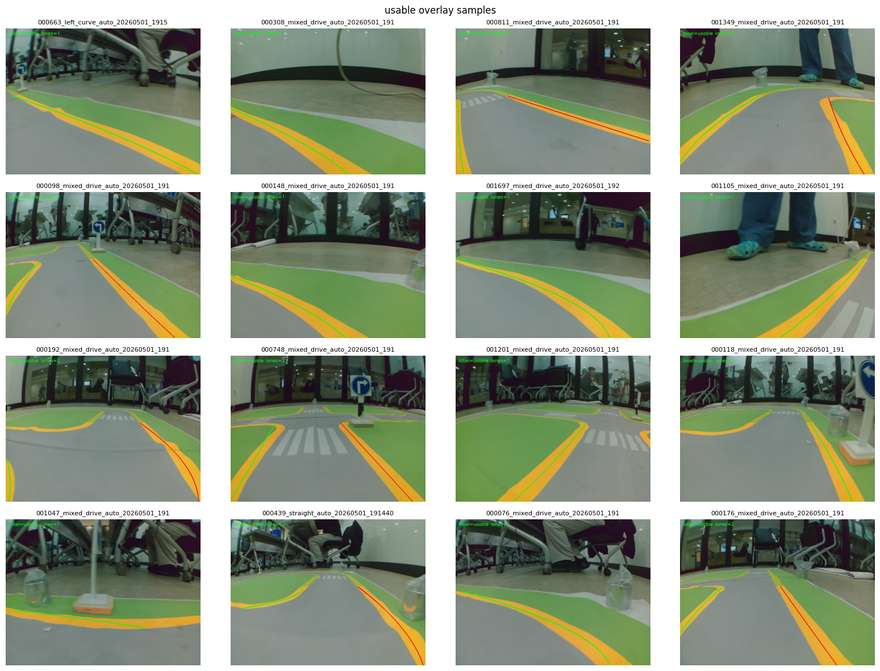

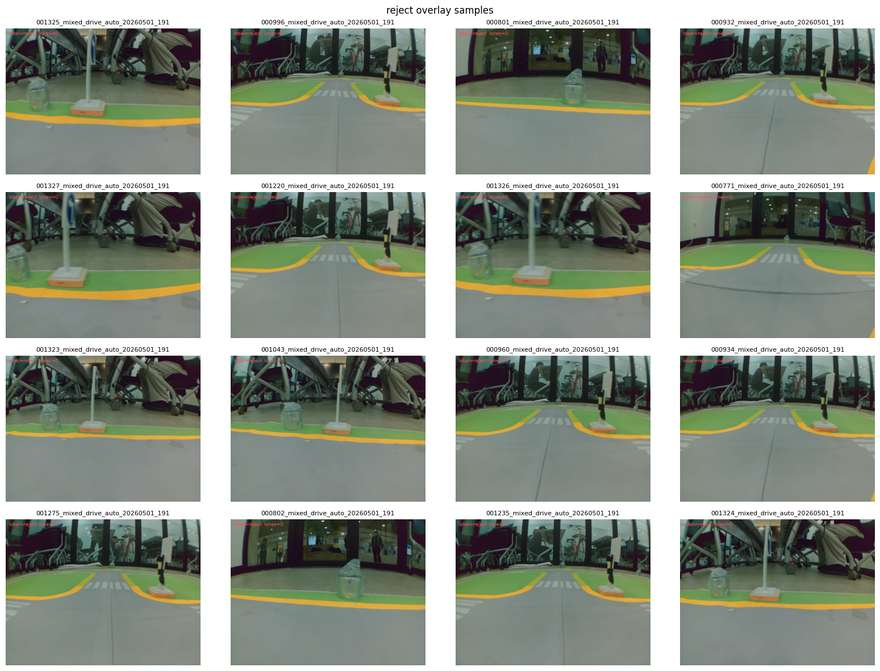

In [6]:
def show_image_grid(paths, title, cols=4, max_images=16):
    paths = list(paths)[:max_images]
    if not paths:
        print('no images:', title)
        return
    rows = math.ceil(len(paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, path in zip(axes, paths):
        img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            ax.set_title('read fail')
            ax.axis('off')
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(path.name[:36], fontsize=8)
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

random.seed(7)
usable_sample = random.sample(usable_overlay_files, min(16, len(usable_overlay_files))) if usable_overlay_files else []
reject_sample = random.sample(reject_overlay_files, min(16, len(reject_overlay_files))) if reject_overlay_files else []
show_image_grid(usable_sample, 'usable overlay samples')
show_image_grid(reject_sample, 'reject overlay samples')


## 6. 시간 순서 샘플 확인

3차 데이터는 실제 주행 중 자동 캡처이므로 랜덤 샘플만 보면 안 됨.

시간 순서로 띄엄띄엄 샘플을 봐야 전체 주행 중 라벨이 언제 무너지는지 감이 생김.


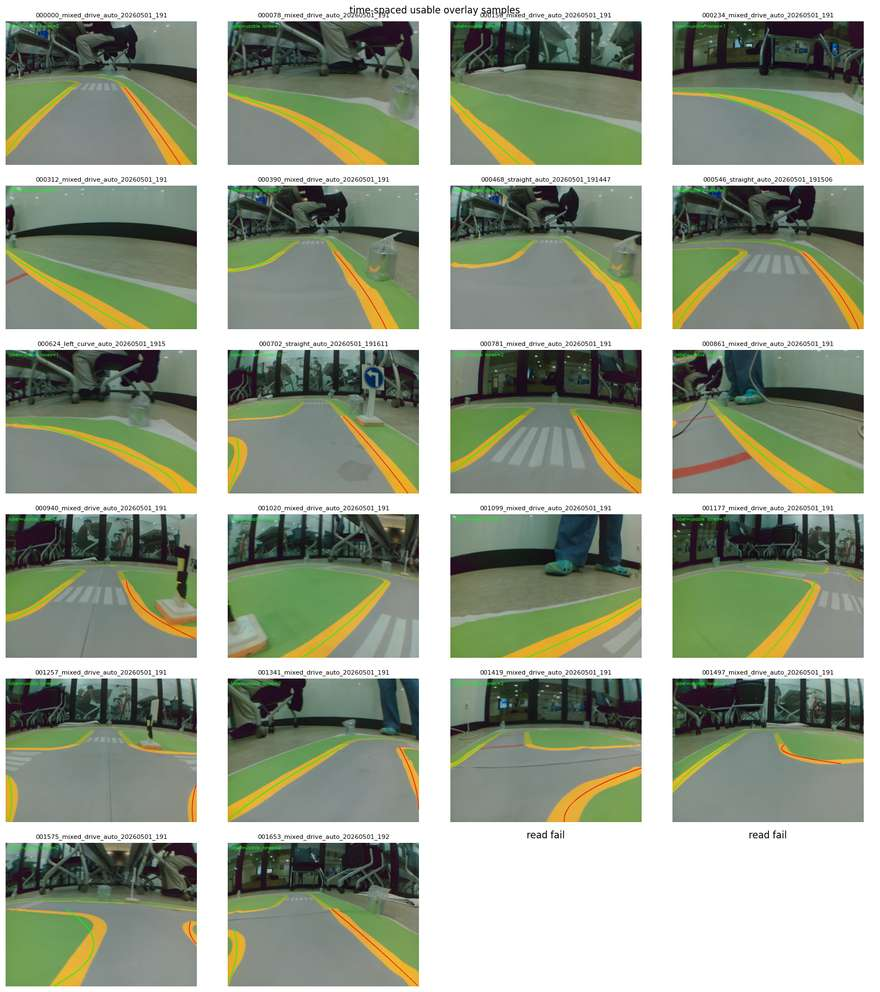

In [7]:
def evenly_spaced(paths, n=24):
    paths = sorted(paths)
    if len(paths) <= n:
        return paths
    idxs = np.linspace(0, len(paths) - 1, n).round().astype(int)
    return [paths[i] for i in idxs]

time_sample = evenly_spaced(usable_overlay_files, 24)
show_image_grid(time_sample, 'time-spaced usable overlay samples', cols=4, max_images=24)


## 7. 감사 요약 저장

다음 노트북으로 넘어가기 전에 감사 결과를 json으로 저장함.

이 요약을 기준으로 field3 데이터를 바로 CULane dataset으로 만들지, 먼저 라벨 보정/필터링을 할지 결정함.


In [8]:
audit_summary = {
    'session_root': str(SESSION_ROOT),
    'counts': counts,
    'manifest_rows': int(len(manifest)),
    'manifest_columns': list(manifest.columns),
    'manifest_scene_counts': manifest['scene'].value_counts(dropna=False).to_dict() if 'scene' in manifest.columns else {},
    'manifest_status_counts': manifest['status'].value_counts(dropna=False).to_dict() if 'status' in manifest.columns else {},
    'missing_manifest_paths': int(len(missing_df)),
    'file_manifest_mismatch_counts': {key: len(values) for key, values in compare.items()},
    'label_lane_count_distribution': label_stats_df['lane_count'].value_counts().sort_index().to_dict(),
    'label_point_total_describe': label_stats_df['point_total'].describe().to_dict(),
    'label_y_span_median_describe': label_stats_df['y_span_median'].describe().to_dict(),
}

summary_path = OUT_DIR / 'field3_audit_summary.json'
summary_path.write_text(json.dumps(audit_summary, indent=2, ensure_ascii=False), encoding='utf-8')
print('saved:', summary_path)
print(json.dumps(audit_summary, indent=2, ensure_ascii=False))


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\00_field3_data_audit\field3_audit_summary.json
{
  "session_root": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\10_lane_autolabel_collection\\outputs\\20260501_191218_lane_autolabel_drive",
  "counts": {
    "raw_files": 1810,
    "label_files": 1810,
    "mask_files": 1810,
    "overlay_files_total": 1810,
    "usable_overlay_files": 1794,
    "reject_overlay_files": 16
  },
  "manifest_rows": 1786,
  "manifest_columns": [
    "idx",
    "timestamp",
    "scene",
    "status",
    "raw",
    "lines",
    "mask",
    "overlay",
    "num_lanes",
    "point_total",
    "median_y_span",
    "mask_support",
    "component_candidates",
    "selected_components",
    "selected_area_total"
  ],
  "manifest_scene_counts": {
    "field_drive": 1786
  },
  "manifest_status_counts": {
    "usable": 1769,
    "reject": 16,
 

## 8. 노트북 실행 후 메모

아직 실행 전임.

실행 후 아래를 적을 것:

```text
manifest와 실제 파일 불일치가 학습에 문제되는 수준인지
usable overlay 품질이 충분한지
reject overlay가 실제로 reject가 맞는지
field3 only dataset builder로 바로 넘어갈지
먼저 라벨 필터링/보정 노트북이 필요한지
```
